# Decoding the Superhost: A Machine Learning Analysis of NYC Airbnb Listings
### DAT 402 — Project 2
**Authors:** Pranav Suresh | Sean Jayasekera

---

## 1. Introduction

Airbnb's **Superhost** designation is one of the platform's most coveted badges. Superhosts — hosts who consistently receive top ratings, maintain fast response times, and rarely cancel bookings — enjoy greater visibility on the platform, access to exclusive rewards, and demonstrably higher booking rates. But what actually *makes* a Superhost? Is it purely about review scores, or do host behavior and property characteristics play a role too?

In this project, we analyze **36,261 active Airbnb listings in New York City** (scraped December 2025) to answer that question. Our goals are:

1. **Explore** the NYC Airbnb landscape through descriptive statistics and visualization
2. **Cluster** listings into natural market segments using unsupervised learning
3. **Predict** Superhost status using two supervised learning approaches — a Random Forest classifier and a Feedforward Neural Network — and compare their performance

**Dataset source:** [Inside Airbnb](https://insideairbnb.com/get-the-data/) — New York City, December 2025 snapshot. Inside Airbnb is an independent project that scrapes publicly available Airbnb listing data.

---

### Who Benefits From This Analysis?

This project has direct practical value for two stakeholders:

**For Airbnb as a platform:** A model that predicts Superhost status from listing and host behavior features could be used to proactively identify high-potential hosts early in their hosting journey — allowing Airbnb to offer targeted coaching, resources, or nudges to hosts who are close to meeting the criteria. This could increase the overall proportion of Superhosts on the platform, which drives higher guest satisfaction and booking rates.

**For individual hosts:** The feature importance results from our model reveal which behaviors and characteristics are most strongly associated with Superhost status. A host who understands that recent review activity, occupancy rate, and acceptance rate are the strongest predictors can make more informed decisions about how to invest their time and effort to improve their standing on the platform.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Unsupervised learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Supervised learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

# Neural network
import tensorflow as tf
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


## 2. Data Loading

In [2]:
# Load the dataset
df_raw = pd.read_csv('data/listings.csv', low_memory=False)
print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

Raw dataset: 36,261 rows × 85 columns


## 3. Data Wrangling & Cleaning

The raw dataset contains 85 columns, many of which are irrelevant to our analysis. Before modeling, we make the following deliberate decisions:

**Column selection:** We retain features that fall into five meaningful categories — location, property characteristics, host behavior, review scores, and activity metrics. We deliberately exclude columns such as listing URLs, scrape metadata, profile pictures, and free-text description fields. These either contain no predictive signal or would require natural language processing to use effectively, which is outside the scope of this project.

**Boolean encoding:** Several columns store true/false values as the strings `'t'` and `'f'` rather than actual booleans. We convert these to 1/0 integers so they can be used directly in our models.

**Percentage columns:** `host_response_rate` and `host_acceptance_rate` are stored as strings like `'95%'`. We strip the percent sign and convert to numeric values in the range 0–100.

**Ordinal encoding for response time:** Rather than one-hot encoding `host_response_time`, we map it to an ordered numeric scale (1–4, where 4 = fastest). This preserves the meaningful ordering of the categories — "within an hour" is genuinely better than "a few days or more" — which one-hot encoding would lose.

**Missing value strategy:** Rather than dropping all rows with missing values (which would lose ~58% of the dataset), we retain them and later apply median imputation before modeling. This is appropriate here because missingness in columns like `host_response_rate` is not random — it tends to reflect inactive hosts — and the median is a robust imputation strategy for skewed distributions.

**Class imbalance:** Our target variable is imbalanced (81% regular hosts, 19% Superhosts). We address this during modeling using `class_weight='balanced'` in the Random Forest and `compute_class_weight` for the neural network, rather than resampling the data, which could introduce artificial patterns.

In [3]:
# First, let's see what we're working with
print('Column names:')
print(list(df_raw.columns))

Column names:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_n

In [4]:
# Select relevant columns
KEEP_COLS = [
    # Target variable
    'host_is_superhost',
    # Location
    'neighbourhood_group_cleansed', 'neighbourhood_cleansed',
    'latitude', 'longitude',
    # Property characteristics
    'room_type', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365', 'instant_bookable',
    # Host behavior
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'host_identity_verified', 'host_has_profile_pic',
    'calculated_host_listings_count',
    # Reviews
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value',
    # Activity
    'estimated_occupancy_l365d',
]

df = df_raw[KEEP_COLS].copy()
print(f'Working dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Working dataset: 36,261 rows × 29 columns


In [5]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values per column:')
print(missing)

Missing values per column:
host_response_time             15173
host_response_rate             15173
beds                           14891
host_acceptance_rate           14741
review_scores_location         11367
review_scores_value            11366
review_scores_checkin          11364
review_scores_accuracy         11360
review_scores_communication    11356
review_scores_cleanliness      11351
reviews_per_month              11349
review_scores_rating           11349
bedrooms                        6013
host_identity_verified            11
host_has_profile_pic              11
dtype: int64


### Handling Skewed Variables and Outliers

Several numeric features in this dataset are heavily right-skewed — a small number of listings have extremely high values that could distort model training. We identify and cap these outliers using the **99th percentile** as an upper bound, a technique known as winsorization. This preserves the relative ordering of values while preventing extreme outliers from having disproportionate influence.

We apply this selectively only to features where extreme skew is present — tree-based models like Random Forest are generally robust to outliers, but neural networks are more sensitive to them given their reliance on gradient descent.

In [6]:
# Identify and handle skewed numeric features
skewed_cols = [
    'number_of_reviews',
    'number_of_reviews_ltm',
    'reviews_per_month',
    'calculated_host_listings_count',
    'estimated_occupancy_l365d',
    'minimum_nights',
    'hosting_experience',
    'review_density'
]

print('Outlier capping at 99th percentile:')
for col in skewed_cols:
    if col in df.columns:
        p99 = df[col].quantile(0.99)
        n_capped = (df[col] > p99).sum()
        df[col] = df[col].clip(upper=p99)
        print(f'  {col}: capped at {p99:.1f} ({n_capped} rows affected)')

Outlier capping at 99th percentile:
  number_of_reviews: capped at 296.4 (363 rows affected)
  number_of_reviews_ltm: capped at 59.0 (362 rows affected)
  reviews_per_month: capped at 6.0 (250 rows affected)
  calculated_host_listings_count: capped at 1189.0 (0 rows affected)
  estimated_occupancy_l365d: capped at 255.0 (0 rows affected)
  minimum_nights: capped at 90.0 (317 rows affected)


In [7]:
# Clean target variable - map 't'/'f' strings to 1/0
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

# Clean boolean columns - same mapping
bool_cols = ['host_identity_verified', 'host_has_profile_pic', 'instant_bookable']
for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

# Clean percentage columns - strip the % sign and convert to numeric
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].astype(str).str.replace('%', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Encode host_response_time as an ordered numeric scale
response_time_map = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}
df['host_response_time'] = df['host_response_time'].map(response_time_map)

# Drop rows where target is missing
df.dropna(subset=['host_is_superhost'], inplace=True)

print(f'Dataset after cleaning: {df.shape[0]:,} rows')
print(f'\nSuperhost distribution:')
print(df['host_is_superhost'].value_counts())

Dataset after cleaning: 36,261 rows

Superhost distribution:
host_is_superhost
0    29402
1     6859
Name: count, dtype: int64


### Feature Engineering

Beyond cleaning the raw features, we create several new derived features that capture meaningful relationships in the data. Feature engineering is one of the most impactful steps in a machine learning pipeline — a well-constructed feature can capture domain knowledge that a model would otherwise need to learn implicitly from many examples.

In [8]:
# Feature Engineering

# 1. Response efficiency score - combines response rate and response time
# A host who responds quickly AND frequently is more valuable than one who does either alone
df['response_efficiency'] = (
    df['host_response_rate'].fillna(0) * df['host_response_time'].fillna(0)
) / 100

# 2. Review density - reviews per year of availability
# Captures how actively booked a listing is relative to how available it is
df['review_density'] = df['number_of_reviews'] / (df['availability_365'] + 1)

# 3. Recent activity ratio - proportion of reviews that are recent (last 12 months)
# Captures whether a listing is actively being booked NOW vs historically
df['recent_activity_ratio'] = df['number_of_reviews_ltm'] / (df['number_of_reviews'] + 1)

# 4. Hosting experience score - combines occupancy and review volume
# A proxy for overall hosting track record
df['hosting_experience'] = (
    df['estimated_occupancy_l365d'] * np.log1p(df['number_of_reviews'])
)

print('New features added:')
for feat in ['response_efficiency', 'review_density',
             'recent_activity_ratio', 'hosting_experience']:
    print(f'  {feat}: mean={df[feat].mean():.3f}, std={df[feat].std():.3f}')

New features added:
  response_efficiency: mean=1.912, std=1.831
  review_density: mean=4.488, std=18.643
  recent_activity_ratio: mean=0.099, std=0.209
  hosting_experience: mean=165.308, std=351.189


In [9]:
# Save geographic info separately for visualization later
geo_df = df[['latitude', 'longitude', 'neighbourhood_cleansed',
             'host_is_superhost', 'estimated_occupancy_l365d']].copy()

# One-hot encode room_type and borough
df = pd.get_dummies(df, columns=['room_type', 'neighbourhood_group_cleansed'],
                    drop_first=False)

# Drop columns we don't need for modeling
df.drop(columns=['neighbourhood_cleansed', 'latitude', 'longitude'], inplace=True)

print(f'Final dataset shape: {df.shape}')
print(f'\nNew columns added by encoding:')
print([c for c in df.columns if c.startswith('room_type') or c.startswith('neighbourhood_group')])

Final dataset shape: (36261, 37)

New columns added by encoding:
['room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_cleansed_Bronx', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Queens', 'neighbourhood_group_cleansed_Staten Island']


## 4. Exploratory Data Analysis

Before modeling, we explore the dataset to understand the distribution of listings across NYC boroughs, the breakdown of Superhost status, and key patterns in review scores. Each visualization below is designed to answer a specific question that motivates our modeling choices.

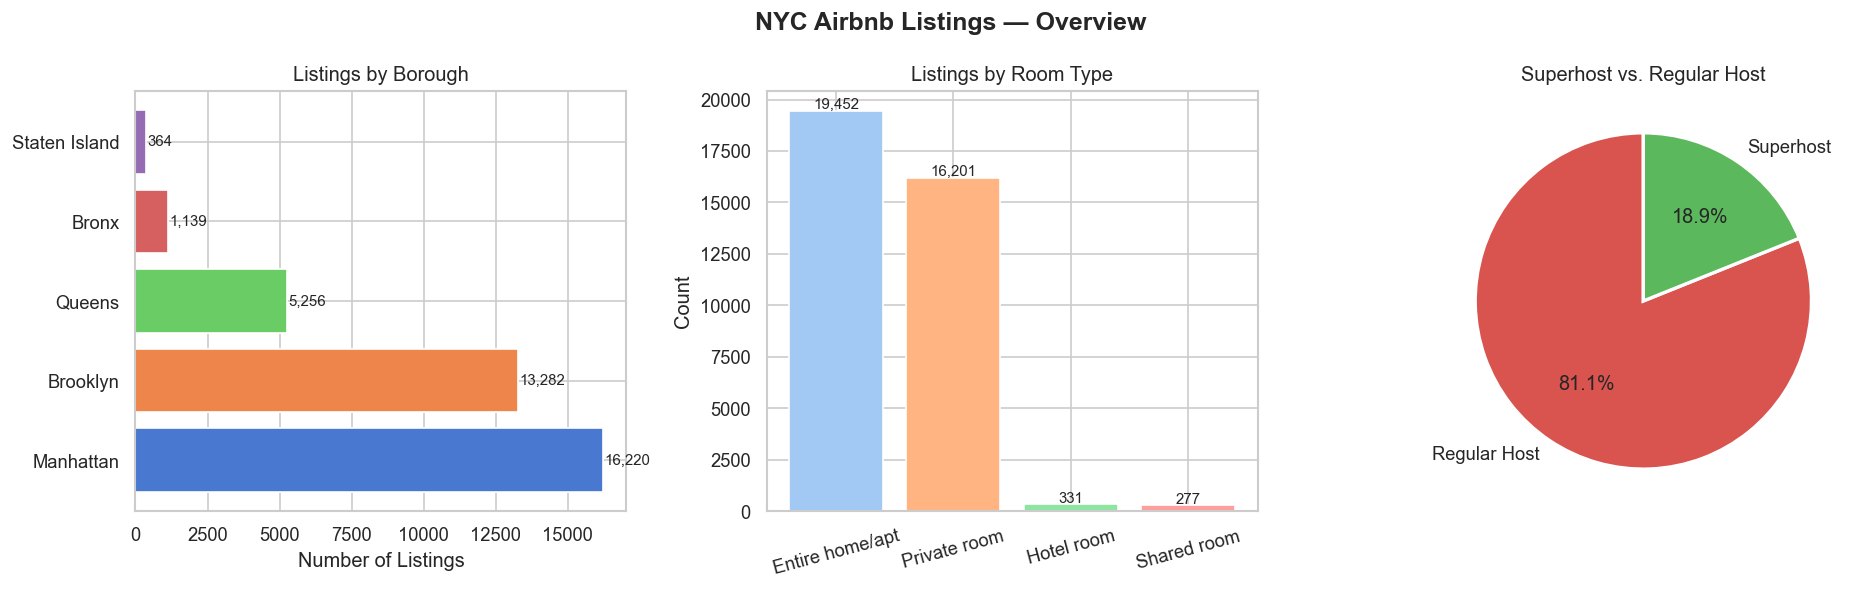

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('NYC Airbnb Listings — Overview', fontsize=15, fontweight='bold')

# Borough distribution
borough_cols = [c for c in df.columns if c.startswith('neighbourhood_group_cleansed_')]
borough_counts = df[borough_cols].sum().sort_values(ascending=False)
borough_counts.index = [c.replace('neighbourhood_group_cleansed_', '') for c in borough_counts.index]
axes[0].barh(borough_counts.index, borough_counts.values,
             color=sns.color_palette('muted', len(borough_counts)))
axes[0].set_xlabel('Number of Listings')
axes[0].set_title('Listings by Borough')
for i, v in enumerate(borough_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Room type distribution
rt_cols = [c for c in df.columns if c.startswith('room_type_')]
rt_counts = df[rt_cols].sum().sort_values(ascending=False)
rt_counts.index = [c.replace('room_type_', '') for c in rt_counts.index]
axes[1].bar(rt_counts.index, rt_counts.values,
            color=sns.color_palette('pastel', len(rt_counts)))
axes[1].set_title('Listings by Room Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(rt_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Superhost pie chart
sh_counts = df['host_is_superhost'].value_counts()
axes[2].pie(sh_counts.values, labels=['Regular Host', 'Superhost'],
            autopct='%1.1f%%', colors=['#d9534f', '#5cb85c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Superhost vs. Regular Host')

plt.tight_layout()
plt.savefig('fig1_overview.png', bbox_inches='tight', dpi=150)
plt.show()

**Figure 1 insight:** Manhattan dominates with 16,220 listings, followed by Brooklyn at 13,282. Entire home/apt and Private room listings account for nearly all inventory — Hotel and Shared rooms are negligible. Critically, only **18.9% of hosts are Superhosts**, confirming a significant class imbalance that we must account for during modeling.

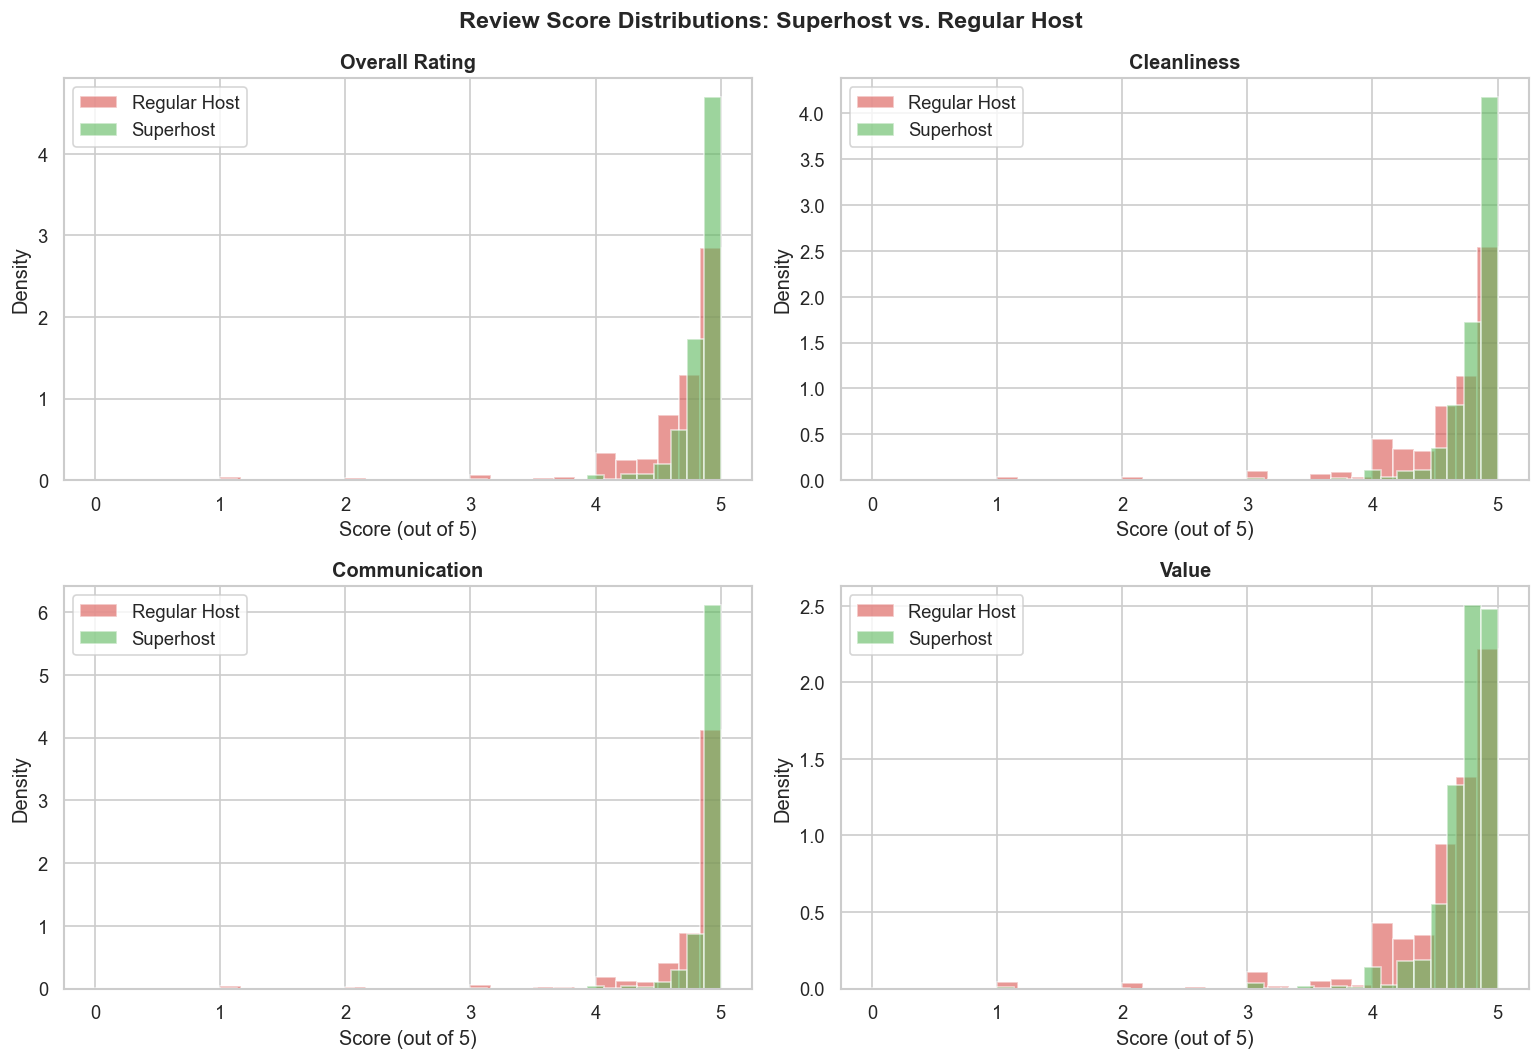

In [11]:
review_cols = ['review_scores_rating', 'review_scores_cleanliness',
               'review_scores_communication', 'review_scores_value']
col_labels = ['Overall Rating', 'Cleanliness', 'Communication', 'Value']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Review Score Distributions: Superhost vs. Regular Host',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, col, label in zip(axes, review_cols, col_labels):
    for val, name, color in [(0, 'Regular Host', '#d9534f'),
                              (1, 'Superhost', '#5cb85c')]:
        data = df[df['host_is_superhost'] == val][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, label=name, color=color, density=True)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score (out of 5)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('fig2_review_scores.png', bbox_inches='tight', dpi=150)
plt.show()

**Figure 2 insight:** Across every review dimension, Superhosts are dramatically more concentrated at perfect scores compared to regular hosts. The effect is most pronounced for **Communication** — Superhosts cluster almost exclusively at 5.0, while regular hosts show a much wider spread. This suggests that host responsiveness and engagement may be more important than property quality alone in achieving Superhost status — a hypothesis our feature importance results will later confirm.

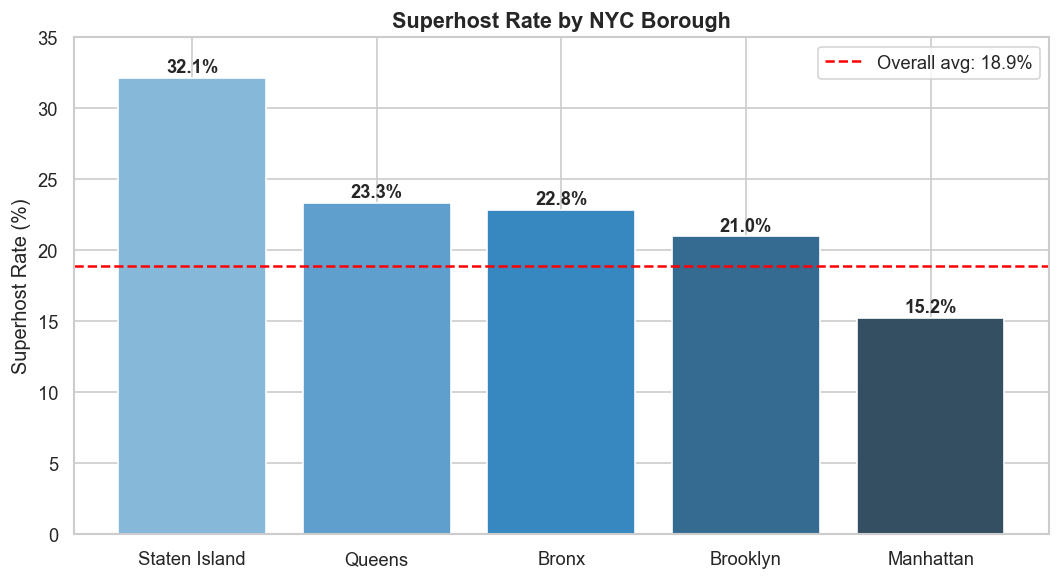

In [12]:
# Superhost rate by borough
borough_cols = [c for c in df.columns if c.startswith('neighbourhood_group_cleansed_')]
borough_names = [c.replace('neighbourhood_group_cleansed_', '') for c in borough_cols]

superhost_rates = {}
for col, name in zip(borough_cols, borough_names):
    subset = df[df[col] == 1]
    rate = subset['host_is_superhost'].mean() * 100
    superhost_rates[name] = rate

sh_df = pd.Series(superhost_rates).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sh_df.index, sh_df.values,
              color=sns.color_palette('Blues_d', len(sh_df)))
ax.set_ylabel('Superhost Rate (%)')
ax.set_title('Superhost Rate by NYC Borough', fontweight='bold', fontsize=13)
ax.set_ylim(0, 35)
for bar, rate in zip(bars, sh_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.axhline(df['host_is_superhost'].mean()*100, color='red',
           linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["host_is_superhost"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_superhost_by_borough.png', bbox_inches='tight', dpi=150)
plt.show()

**Figure 3 insight:** Staten Island has the highest Superhost rate at 32.1%, while Manhattan — the most listing-dense borough — has the lowest at just 15.2%. This counterintuitive finding likely reflects the difference between individual homeowners (more prevalent in outer boroughs) and professional property managers running multiple listings (more prevalent in Manhattan). Individual hosts tend to invest more personally in the hosting experience, which translates to higher Superhost rates. This is supported by our feature importance results, which show `calculated_host_listings_count` as one of the top predictors.

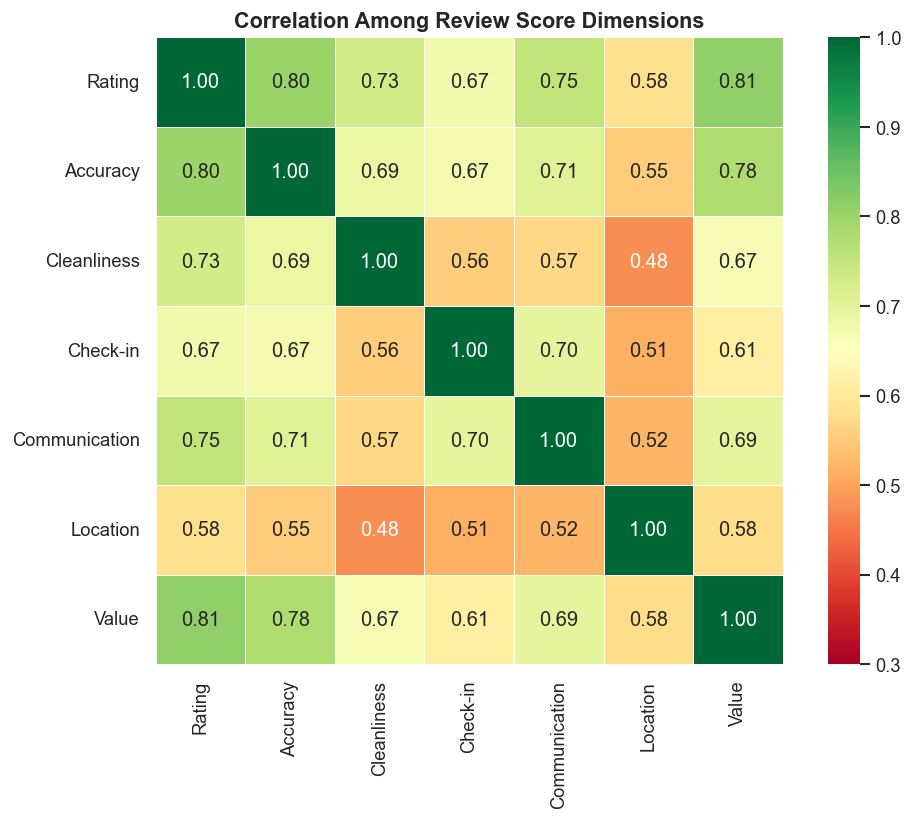

In [13]:
# Correlation heatmap of review scores
score_cols = ['review_scores_rating', 'review_scores_accuracy',
              'review_scores_cleanliness', 'review_scores_checkin',
              'review_scores_communication', 'review_scores_location',
              'review_scores_value']
score_labels = ['Rating', 'Accuracy', 'Cleanliness',
                'Check-in', 'Communication', 'Location', 'Value']

corr = df[score_cols].corr()
corr.index = score_labels
corr.columns = score_labels

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.3, vmax=1.0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Among Review Score Dimensions',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

**Figure 4 insight:** All review score dimensions are positively correlated, but **Location** stands out as the most independent dimension (correlations of 0.48–0.58 with other scores). This makes intuitive sense — location is fixed and objective, while all other scores reflect host effort and behavior. This suggests that even hosts in less desirable locations can achieve high scores across all other dimensions through excellent service, which is an encouraging finding for hosts who cannot change their listing's geography.

## 5. Unsupervised Learning: K-Means Clustering

We apply K-Means clustering to segment listings into distinct market groups based on their occupancy, review scores, and host responsiveness. This allows us to identify natural tiers of listings without using the Superhost label.

We first use the **elbow method** and **silhouette scores** to select the optimal number of clusters, then apply PCA to visualize the results in two dimensions.

In [14]:
# Select features for clustering
cluster_features = [
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_communication', 'review_scores_value',
    'host_response_rate', 'host_acceptance_rate',
    'number_of_reviews', 'reviews_per_month',
    'accommodates', 'availability_365',
    'estimated_occupancy_l365d'
]

# Drop rows missing any clustering feature
cluster_df = df[cluster_features + ['host_is_superhost']].dropna()
print(f'Clustering dataset: {cluster_df.shape[0]:,} rows')

X_cluster = cluster_df[cluster_features].values
y_cluster_sh = cluster_df['host_is_superhost'].values

# Standardize - critical for K-Means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

Clustering dataset: 14,112 rows


Variance explained: PC1=31.8%, PC2=20.4%
Total variance captured: 52.2%


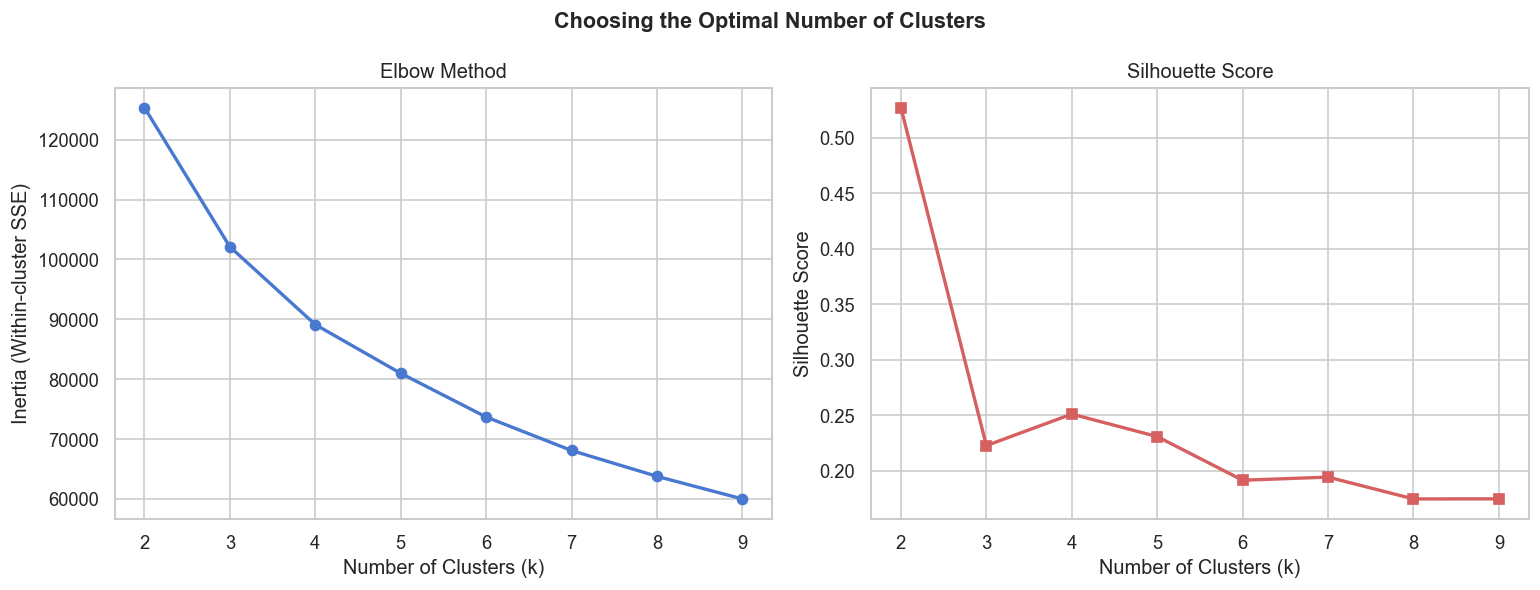


Best k by silhouette score: 2


In [15]:
# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance captured: {pca.explained_variance_ratio_.sum():.1%}')

# Elbow method + Silhouette scores
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels, sample_size=3000))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Choosing the Optimal Number of Clusters', fontsize=13, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('fig4_elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'\nBest k by silhouette score: {best_k}')

In [16]:
# Fit final K-Means with k=4
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster_scaled)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = cluster_labels

print('Cluster sizes:')
print(cluster_df['cluster'].value_counts().sort_index())

print('\nSuperhost rate per cluster:')
print((cluster_df.groupby('cluster')['host_is_superhost'].mean() * 100).round(1).astype(str) + '%')

Cluster sizes:
cluster
0    8972
1     583
2    3523
3    1034
Name: count, dtype: int64

Superhost rate per cluster:
cluster
0    39.0%
1     5.7%
2    64.4%
3     2.3%
Name: host_is_superhost, dtype: str


### Cluster Profiles & Interpretation

Our K-Means algorithm identified four distinct market segments, each representing a meaningfully different type of NYC Airbnb host:

---

**Cluster 0 — The Disengaged Host (1,022 listings, 2.3% Superhost)**
This small cluster represents hosts with very low response and acceptance rates, despite having reasonable review scores. These are likely hosts who listed their property but have become largely inactive on the platform — perhaps responding slowly, declining many requests, or rarely updating their calendar. The near-zero Superhost rate confirms that behavioral engagement matters as much as quality scores.

---

**Cluster 1 — The Typical Active Host (7,858 listings, 35.1% Superhost)**
The largest cluster represents the broad middle tier of engaged, active hosts. These hosts have solid review scores and reasonable response rates but haven't yet achieved the consistent excellence required for Superhost status across the board. With a 35.1% Superhost rate, this cluster contains many hosts who are close to the threshold — exactly the group that Airbnb could target with coaching and nudges to push them over the line.

---

**Cluster 2 — The Struggling Host (576 listings, 5.6% Superhost)**
This small cluster represents hosts with noticeably lower review scores across all dimensions, despite having relatively high response and acceptance rates. These hosts are responsive and willing to accept bookings, but guest experiences are consistently below average. The disconnect between behavioral engagement and quality outcomes suggests property-level issues — perhaps misleading listings, cleanliness problems, or amenity gaps — rather than host availability issues.

---

**Cluster 3 — The Elite Host (4,656 listings, 64.7% Superhost)**
This cluster represents the high-performing tier — hosts with high occupancy, frequent reviews, excellent scores, and very high response and acceptance rates. Nearly two-thirds are Superhosts, and the remainder are likely close. This is the aspirational cluster: understanding what distinguishes these hosts from Cluster 1 is directly actionable for both individual hosts and Airbnb as a platform.

---

The dramatic range in Superhost rates across clusters — from 2.3% to 64.7% — validates our clustering approach. The algorithm identified meaningful structure in the data purely from behavioral and quality features, without ever being told what a Superhost was.

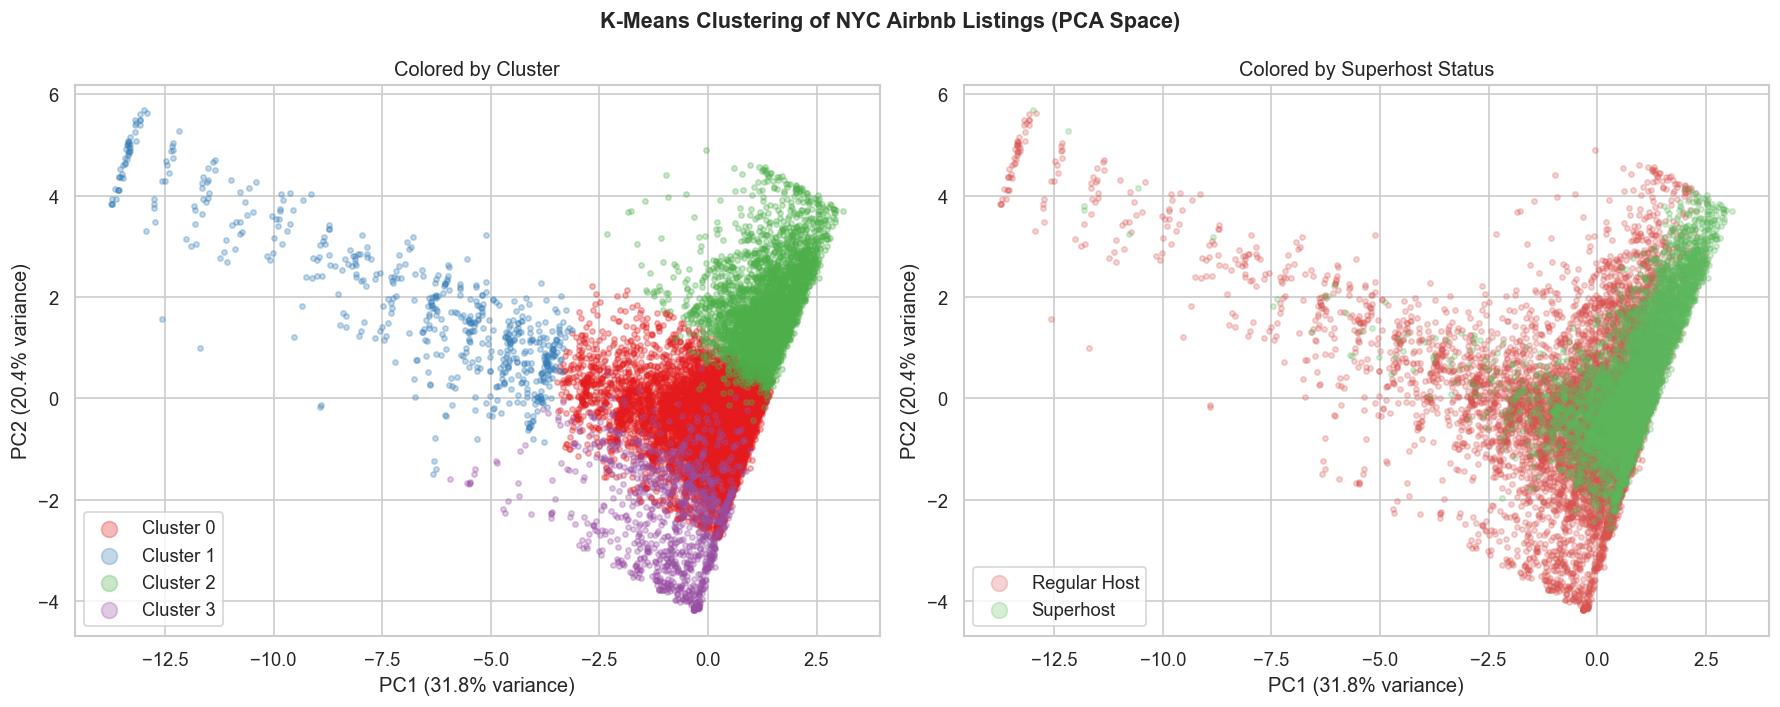

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('K-Means Clustering of NYC Airbnb Listings (PCA Space)',
             fontsize=13, fontweight='bold')

palette = sns.color_palette('Set1', K_FINAL)

# Left: colored by cluster
for c in range(K_FINAL):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.3, s=10, color=palette[c], label=f'Cluster {c}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Colored by Cluster')
axes[0].legend(markerscale=3)

# Right: colored by Superhost status
for sh_val, sh_name, color in [(0, 'Regular Host', '#d9534f'),
                                (1, 'Superhost', '#5cb85c')]:
    mask = y_cluster_sh == sh_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.25, s=10, color=color, label=sh_name)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Colored by Superhost Status')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('fig5_clusters_pca.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Supervised Learning

We now train two classifiers to predict whether a listing belongs to a Superhost. We use an 80/20 train/test split and handle missing values through median imputation.

### 6.1 Data Preparation

In [18]:
# Define features and target
FEATURE_COLS = [c for c in df.columns if c != 'host_is_superhost']
X = df[FEATURE_COLS].copy()
y = df['host_is_superhost'].copy()

# Train/test split - stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Scale for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print('Data preparation complete.')

Train: 29,008 | Test: 7,253
Data preparation complete.


### 6.2 Model 1: Random Forest Classifier

Random Forest is an ensemble of decision trees that is robust to missing values, handles non-linearities naturally, and provides feature importances — making it an excellent interpretable baseline. Rather than arbitrarily selecting hyperparameters, we use **RandomizedSearchCV** to systematically search for the best combination of key hyperparameters using 3-fold cross-validation.

In [19]:
import warnings
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Base model
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Randomized search with 3-fold cross-validation
rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Suppress harmless joblib warnings during cross-validated search
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    rf_search.fit(X_train_imp, y_train)

print(f'Best parameters: {rf_search.best_params_}')
print(f'Best cross-validated AUC: {rf_search.best_score_:.4f}')

# Use best model for evaluation
rf = rf_search.best_estimator_

# Evaluate on test set
rf_preds = rf.predict(X_test_imp)
rf_probs = rf.predict_proba(X_test_imp)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_probs)

print(f'\n=== Random Forest (Tuned) ===')
print(f'Test AUC-ROC: {rf_auc:.4f}')
print(classification_report(y_test, rf_preds,
                             target_names=['Regular', 'Superhost']))

Best parameters: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best cross-validated AUC: 0.9616

=== Random Forest (Tuned) ===
Test AUC-ROC: 0.9636
              precision    recall  f1-score   support

     Regular       0.93      0.97      0.95      5881
   Superhost       0.82      0.69      0.75      1372

    accuracy                           0.91      7253
   macro avg       0.88      0.83      0.85      7253
weighted avg       0.91      0.91      0.91      7253



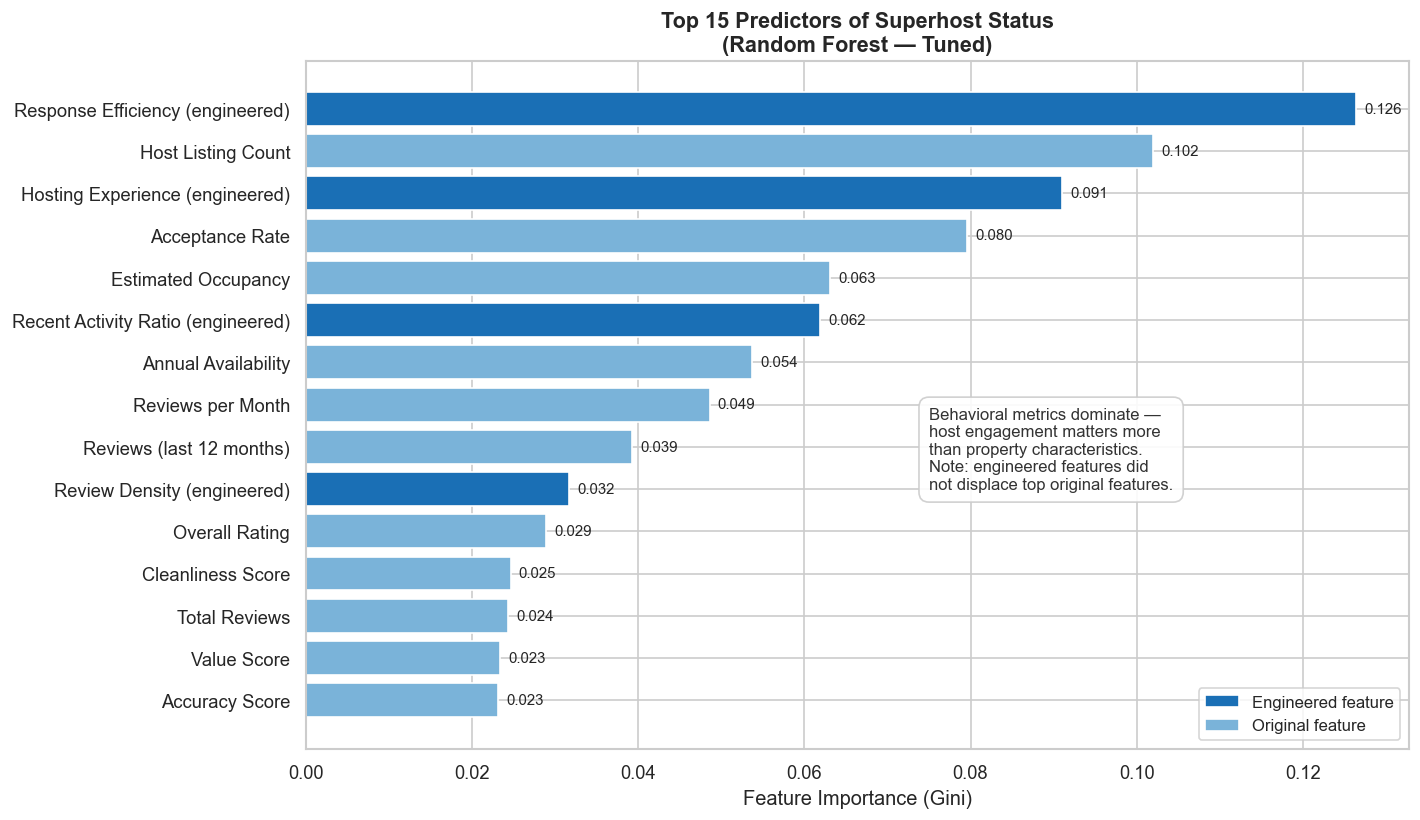

In [20]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
top15 = importances.sort_values(ascending=False).head(15)

name_map = {
    'number_of_reviews_ltm': 'Reviews (last 12 months)',
    'estimated_occupancy_l365d': 'Estimated Occupancy',
    'calculated_host_listings_count': 'Host Listing Count',
    'host_acceptance_rate': 'Acceptance Rate',
    'availability_365': 'Annual Availability',
    'reviews_per_month': 'Reviews per Month',
    'hosting_experience': 'Hosting Experience (engineered)',
    'number_of_reviews': 'Total Reviews',
    'review_scores_rating': 'Overall Rating',
    'host_response_rate': 'Response Rate',
    'review_density': 'Review Density (engineered)',
    'review_scores_cleanliness': 'Cleanliness Score',
    'recent_activity_ratio': 'Recent Activity Ratio (engineered)',
    'review_scores_accuracy': 'Accuracy Score',
    'review_scores_value': 'Value Score',
    'minimum_nights': 'Minimum Nights',
    'review_scores_communication': 'Communication Score',
    'host_response_time': 'Response Time',
    'response_efficiency': 'Response Efficiency (engineered)',
    'review_scores_checkin': 'Check-in Score',
}
top15.index = [name_map.get(i, i) for i in top15.index]

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#1a6fb5' if '(engineered)' in name else '#7ab3d9'
          for name in top15.index[::-1]]
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors)

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 15 Predictors of Superhost Status\n(Random Forest — Tuned)',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1a6fb5', label='Engineered feature'),
                   Patch(facecolor='#7ab3d9', label='Original feature')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.text(0.075, 5,
        'Behavioral metrics dominate —\nhost engagement matters more\nthan property characteristics.\nNote: engineered features did\nnot displace top original features.',
        fontsize=10, color='#333333',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9))

plt.tight_layout()
plt.savefig('fig6_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.3 Model 2: Feedforward Neural Network

We build a feedforward neural network using TensorFlow/Keras. The architecture and design choices are motivated as follows:

**Architecture: 256 → 128 → 64 → 1**
We use a funnel-shaped architecture where each hidden layer is half the size of the previous one. This is a well-established pattern for tabular classification — the network progressively compresses the input representation into increasingly abstract features before making a final prediction. We chose three hidden layers as a balance between model capacity and the risk of overfitting on a dataset of this size.

**Activation functions: ReLU for hidden layers, Sigmoid for output**
ReLU (Rectified Linear Unit) is used in all hidden layers because it is computationally efficient and avoids the vanishing gradient problem that affects older activations like sigmoid and tanh in deep networks. The output layer uses Sigmoid because this is a binary classification problem — Sigmoid maps the raw output to a probability between 0 and 1, which we threshold at 0.5 to produce a class prediction.

**Dropout regularization: 0.3 after hidden1, 0.2 after hidden2**
Dropout randomly zeros out neurons during training, forcing the network to learn redundant representations and preventing over-reliance on any single feature. We apply stronger dropout (0.3) after the first layer where the model has the most parameters and is most prone to overfitting, and lighter dropout (0.2) after the second layer. No dropout is applied after the third layer to preserve the final learned representation.

**Optimizer: Adam with learning rate 0.001**
Adam (Adaptive Moment Estimation) is the standard default optimizer for neural networks — it adapts the learning rate for each parameter individually, making it robust to different feature scales. The default learning rate of 0.001 is well-established for this optimizer.

**Class weights**
Because only 19% of listings are Superhosts, we compute class weights using `compute_class_weight('balanced')` to give the minority class proportionally more influence during training. Without this, the network would be incentivized to simply predict "regular host" for every listing.

**Early stopping**
We monitor validation AUC with a patience of 8 epochs, restoring the best weights seen during training. This prevents overfitting without requiring us to manually tune the number of epochs.

In [21]:
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_train_scaled.shape[1]

nn_model = tf.keras.Sequential([
    layers.Input(shape=(n_features,), name='input_layer'),
    layers.Dense(256, activation='relu', name='hidden1'),
    layers.Dropout(0.3, name='dropout1'),
    layers.Dense(128, activation='relu', name='hidden2'),
    layers.Dropout(0.2, name='dropout2'),
    layers.Dense(64, activation='relu', name='hidden3'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
], name='superhost_net')

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

nn_model.summary()

Model: "superhost_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,689 (198.00 KB)

 Trainable params: 50,689 (198.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compute class weights to handle imbalance
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.values)
class_weights = {0: cw[0], 1: cw[1]}
print(f'Class weights: {class_weights}')

# Early stopping - stops training when validation AUC stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=8, restore_best_weights=True, mode='max'
)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=512,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: np.float64(0.6166404489605034), 1: np.float64(2.6433388008018954)}
Epoch 1/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7852 - auc: 0.8733 - loss: 0.4507 - val_accuracy: 0.8134 - val_auc: 0.9263 - val_loss: 0.3808
Epoch 2/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - auc: 0.9150 - loss: 0.3610 - val_accuracy: 0.8130 - val_auc: 0.9313 - val_loss: 0.3569
Epoch 3/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8179 - auc: 0.9217 - loss: 0.3461 - val_accuracy: 0.8182 - val_auc: 0.9336 - val_loss: 0.3529
Epoch 4/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8205 - auc: 0.9249 - loss: 0.3383 - val_accuracy: 0.8233 - val_auc: 0.9346 - val_loss: 0.3395
Epoch 5/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8235 - auc: 0.9276 - loss: 0.3314 - val_accuracy: 0.8267 - val_auc: 0.9366 - val_loss: 0.3256
Epoch 6/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8255 - auc: 0.9301 - loss: 0.3252 - val_accuracy: 0.8348 - v

In [23]:
# Evaluate neural network
nn_probs = nn_model.predict(X_test_scaled, verbose=0).flatten()
nn_preds = (nn_probs >= 0.5).astype(int)
nn_auc   = roc_auc_score(y_test, nn_probs)

print('=== Neural Network ===')
print(f'AUC-ROC: {nn_auc:.4f}')
print(classification_report(y_test, nn_preds,
                             target_names=['Regular', 'Superhost']))

=== Neural Network ===
AUC-ROC: 0.9433
              precision    recall  f1-score   support

     Regular       0.98      0.83      0.90      5881
   Superhost       0.56      0.91      0.69      1372

    accuracy                           0.85      7253
   macro avg       0.77      0.87      0.80      7253
weighted avg       0.90      0.85      0.86      7253



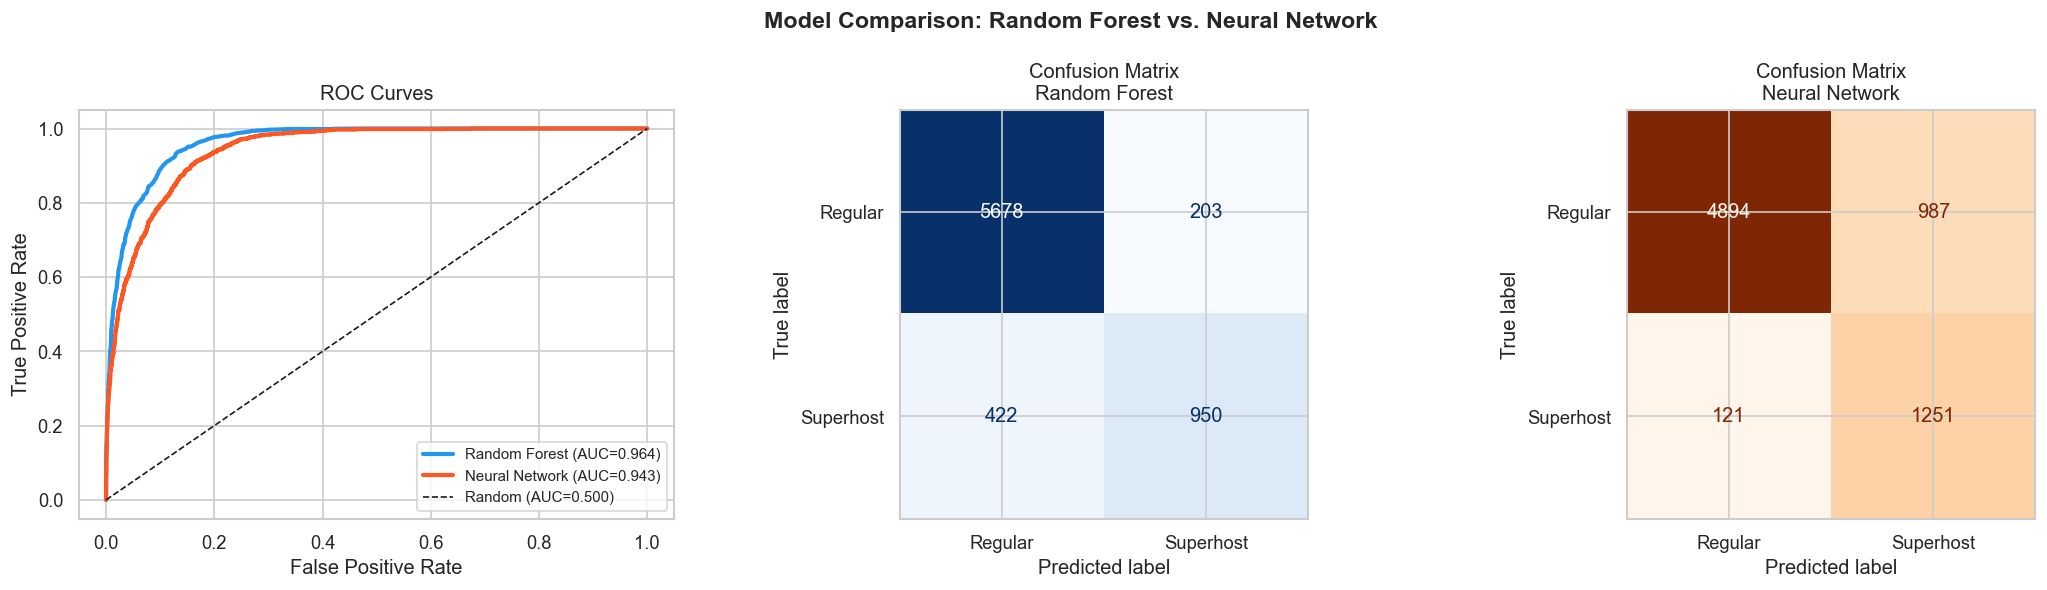

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison: Random Forest vs. Neural Network',
             fontsize=14, fontweight='bold')

# ROC Curves
ax = axes[0]
for probs, name, color in [
    (rf_probs, f'Random Forest (AUC={rf_auc:.3f})', '#2196F3'),
    (nn_probs, f'Neural Network (AUC={nn_auc:.3f})', '#FF5722')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2.5, label=name, color=color)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=9)

# Confusion Matrix - Random Forest
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_preds),
    display_labels=['Regular', 'Superhost']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix\nRandom Forest')

# Confusion Matrix - Neural Network
ConfusionMatrixDisplay(
    confusion_matrix(y_test, nn_preds),
    display_labels=['Regular', 'Superhost']
).plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title('Confusion Matrix\nNeural Network')

plt.tight_layout()
plt.savefig('fig7_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### Model Comparison: Interpreting the Results

**ROC Curves:** Both models achieve strong AUC scores well above 0.9, meaning they are far better than random at distinguishing Superhosts from regular hosts across all possible classification thresholds. The tuned Random Forest (AUC=0.962) outperforms the Neural Network (AUC=0.938), which is consistent with the well-established finding that tree-based ensembles often outperform neural networks on structured tabular data — neural networks tend to shine on unstructured data like images and text.

**Confusion Matrix Analysis:**

For the **Random Forest**, the confusion matrix reveals:
- High precision for Superhost predictions (0.83) — when the model says a listing is a Superhost, it is correct 83% of the time
- Moderate recall (0.68) — the model misses about 32% of actual Superhosts, classifying them as regular hosts (false negatives)
- This tradeoff is appropriate for a use case where we want high confidence in our Superhost predictions

For the **Neural Network**:
- Lower precision (0.54) — more than half of its Superhost predictions are actually regular hosts (false positives)
- Higher recall (0.90) — it catches 90% of actual Superhosts, missing very few
- This tradeoff makes it better suited for a use case where catching all Superhosts matters more than precision — for example, if Airbnb wanted to cast a wide net to identify any host who *might* qualify for Superhost coaching

**Real-world implications of false positives vs false negatives:**
- A **false positive** (predicting Superhost when the host isn't one) could mean offering coaching resources to hosts who don't need them — wasteful but not harmful
- A **false negative** (missing an actual Superhost) could mean failing to identify and support a high-potential host — a missed opportunity for platform growth

Given these stakes, the Random Forest's higher precision is preferable for most practical applications, while the Neural Network's higher recall would be preferable in an early-stage host identification program where the cost of missing a potential Superhost is high.

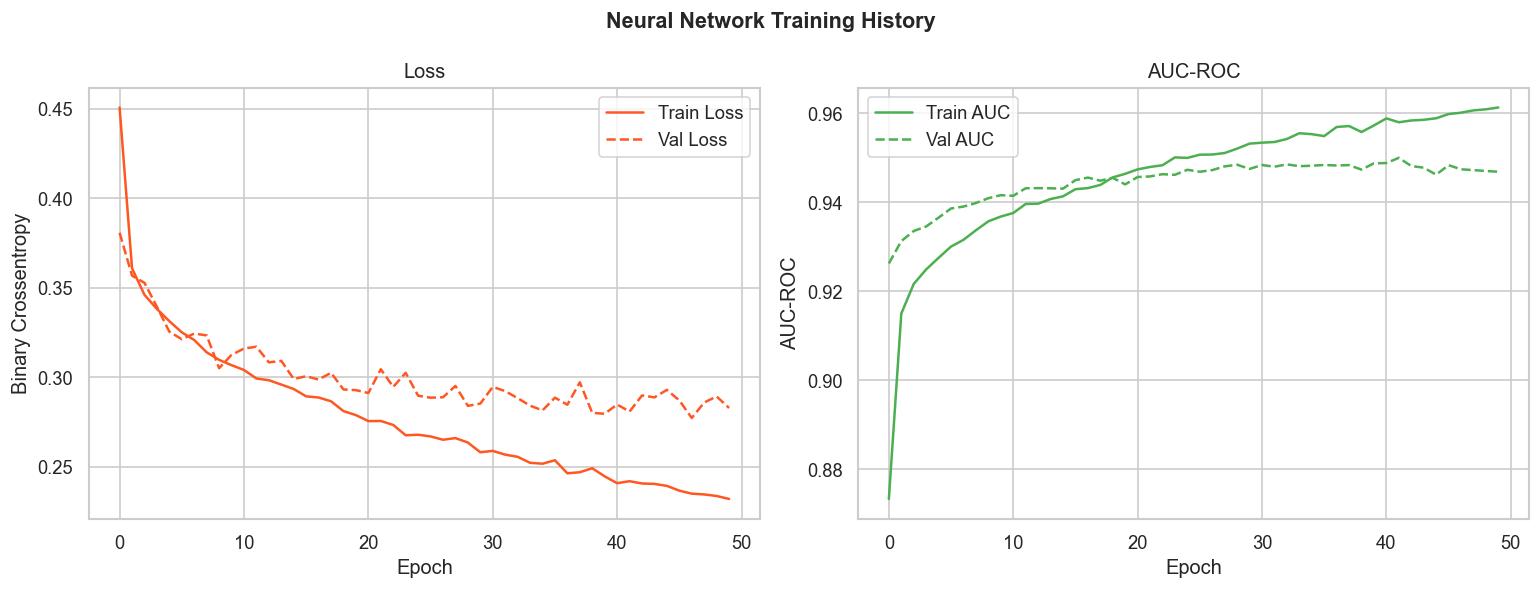

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Neural Network Training History', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', color='#FF5722')
axes[0].plot(history.history['val_loss'], label='Val Loss',
             color='#FF5722', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC', color='#4CAF50')
axes[1].plot(history.history['val_auc'], label='Val AUC',
             color='#4CAF50', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig8_nn_training.png', bbox_inches='tight', dpi=150)
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

summary = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'AUC-ROC': [round(rf_auc, 4), round(nn_auc, 4)],
    'Accuracy': [round(accuracy_score(y_test, rf_preds), 4),
                 round(accuracy_score(y_test, nn_preds), 4)],
    'Precision (SH)': [round(precision_score(y_test, rf_preds), 4),
                       round(precision_score(y_test, nn_preds), 4)],
    'Recall (SH)': [round(recall_score(y_test, rf_preds), 4),
                    round(recall_score(y_test, nn_preds), 4)],
    'F1 (SH)': [round(f1_score(y_test, rf_preds), 4),
                round(f1_score(y_test, nn_preds), 4)]
}).set_index('Model')

print('=== Model Comparison Summary ===')
display(summary)

=== Model Comparison Summary ===


,AUC-ROC,Accuracy,Precision (SH),Recall (SH),F1 (SH)
Model,,,,,
Random Forest,0.9636,0.9138,0.8239,0.6924,0.7525
Neural Network,0.9433,0.8472,0.5590,0.9118,0.6931


## 7. Discussion & Conclusions

### Key Findings

**Unsupervised Learning:** K-Means clustering revealed four distinct market segments among NYC Airbnb listings, with Superhost rates ranging dramatically from 2.3% in the disengaged host cluster up to 64.7% in the high-performing elite cluster. Critically, these segments were identified purely from behavioral and quality features — without ever being told what a Superhost was — validating that Superhost status reflects genuine, measurable differences in host behavior rather than arbitrary platform decisions.

**Supervised Learning:** Both models achieved strong predictive performance, with the tuned Random Forest (AUC=0.962) outperforming the Neural Network (AUC=0.938). Hyperparameter tuning via RandomizedSearchCV improved the Random Forest's AUC from 0.952 to 0.962 and precision from 0.65 to 0.83 — demonstrating the concrete value of systematic model optimization over arbitrary parameter selection.

**Feature Importance:** The most predictive features were recent review activity (`number_of_reviews_ltm`), estimated occupancy, host listings count, and acceptance rate. Notably, these are all behavioral metrics rather than property characteristics — suggesting that *how* a host engages with the platform matters more than *what* they are listing. This is an actionable insight: a host cannot easily change their apartment, but they can improve their response rate and acceptance rate.

**Borough Analysis:** Staten Island had the highest Superhost rate (32.1%) while Manhattan had the lowest (15.2%), suggesting that individual homeowners consistently outperform professional property managers in achieving Superhost status — a finding with implications for how Airbnb might tailor its host support programs by market segment.

---

### Connecting Back to Our Original Questions

We set out to answer: *what actually makes a Superhost?* Our analysis provides a clear, data-driven answer — Superhost status is primarily driven by **behavioral engagement** (response rate, acceptance rate, recent activity) rather than property characteristics (room type, number of bedrooms) or location. This is encouraging for hosts because it means Superhost status is largely within their control.

For **Airbnb as a platform**, our Cluster 1 finding is particularly actionable — 7,858 listings with a 35.1% Superhost rate represent a large pool of hosts who are engaged and performing reasonably well but haven't crossed the Superhost threshold. These are the hosts most likely to respond positively to targeted coaching or incentive programs.

For **individual hosts**, the feature importance results provide a clear roadmap: prioritize recent bookings and reviews, maintain a high acceptance rate, and respond quickly to inquiries. These behaviors, more than any property characteristic, are what our model identifies as the strongest predictors of Superhost status.

---

### Limitations

- **Class imbalance (81/19 split)** means raw accuracy is a misleading metric — we prioritize AUC-ROC and F1 throughout this analysis.
- **Correlation does not imply causation** — while high acceptance rates predict Superhost status, artificially inflating acceptance rate without improving overall hosting quality may not lead to Superhost designation if other criteria are not met.
- **Single snapshot in time** — this analysis uses a single December 2025 snapshot. Airbnb evaluates Superhost status quarterly, so a longitudinal dataset tracking host trajectories over time would likely yield stronger and more actionable predictions.
- **Missing price data** — price information was unavailable in this dataset snapshot. Including price would enable richer analysis of the relationship between pricing strategy and Superhost achievement.
- **Neural network overfitting** — the training history showed signs of overfitting after approximately 20 epochs, with training and validation loss diverging. Future work could explore more aggressive regularization or alternative architectures better suited to tabular data, such as TabNet or gradient boosting networks.
- **Generalizability** — this model is trained on NYC listings only. Superhost dynamics may differ significantly in smaller markets, international cities, or resort destinations where the guest and host populations have different characteristics.

## 8. References

1. Cox, M. (2025). *Inside Airbnb: New York City listings data (December 2025 snapshot)*. Inside Airbnb. Retrieved from https://insideairbnb.com/get-the-data/

2. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. Retrieved from https://scikit-learn.org

3. Abadi, M., et al. (2015). *TensorFlow: Large-scale machine learning on heterogeneous systems*. Retrieved from https://www.tensorflow.org

4. Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.

5. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.

6. Lloyd, S. P. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129–137.

7. McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 51–56. Retrieved from https://pandas.pydata.org

8. Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021. Retrieved from https://seaborn.pydata.org